# Comparativa Completa de Modelos Seq2Seq

## FastText vs BERT | Frozen vs Fine-tuned

En este notebook vamos a comparar **4 configuraciones** de embeddings:

### Embeddings No-Contextuales (FastText)
1. **FastText Frozen**: Embeddings pre-entrenados "frozen", en estos se mantienen los weights fijos durante todo el entrenamiento, que esto nos interesa para evaluar la capacidad de nuestro modelo para aprender únicamente a partir de la arquitectura Seq2Seq, sin modificar la representación de las palabras.

2. **FastText Fine-tuned**: En este caso, los mismos embeddings FastText pre-entrenados nos sirven como inicialización, pero si que se actualizan mientras aprenden. Con estos esperamos mejores resutlados, ya que potenicalmente deberían capturar mejor matices financieros o ciertas terminologias frecuentes en nuestos textos

### Embeddings Contextuales (BERT)
3. **BERT Frozen**: BERT siguiendo el mismo caso que los FastText empleando "frozen".
4. **BERT Fine-tuned**: BERT siguiento mismo caso que los FasText, empleando fine-tuning para que sus pesos se actualicen durante el entrenamiento

## 1. Importar Librerías

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import KeyedVectors
from transformers import BertModel, BertTokenizer
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42
MAX_HEADLINE_LEN = 20
MAX_ARTICLE_LEN = 512
HIDDEN_SIZE = 256
EMBEDDING_DIM = 300
BERT_DIM = 768

PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'
UNK_TOKEN = '<UNK>'

c:\Users\mpsua\anaconda3\envs\dl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Definir Clases (FastText)

In [2]:
class Vocabulary:
    def __init__(self):
        self.word2idx = {PAD_TOKEN: 0, SOS_TOKEN: 1, EOS_TOKEN: 2, UNK_TOKEN: 3}
        self.idx2word = {0: PAD_TOKEN, 1: SOS_TOKEN, 2: EOS_TOKEN, 3: UNK_TOKEN}
        self.n_words = 4
    
    def add_sentence(self, sentence):
        for word in sentence.split():
            if word not in self.word2idx:
                self.word2idx[word] = self.n_words
                self.idx2word[self.n_words] = word
                self.n_words += 1

class EncoderRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, embedding_weights=None, freeze_embeddings=False):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        if embedding_weights is not None:
            self.embedding = nn.Embedding.from_pretrained(embedding_weights, freeze=freeze_embeddings, padding_idx=0)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_size, batch_first=True, bidirectional=True)
    
    def forward(self, input_seq, input_lengths):
        embedded = self.embedding(input_seq)
        packed = nn.utils.rnn.pack_padded_sequence(embedded, input_lengths.cpu(), batch_first=True, enforce_sorted=False)
        outputs, hidden = self.gru(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True)
        outputs = outputs[:, :, :self.hidden_size] + outputs[:, :, self.hidden_size:]
        hidden = hidden[0] + hidden[1]
        return outputs, hidden.unsqueeze(0)

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)
    
    def forward(self, query, keys):
        scores = self.Va(torch.tanh(self.Wa(query.unsqueeze(1)) + self.Ua(keys)))
        weights = torch.softmax(scores.squeeze(2), dim=1)
        context = torch.bmm(weights.unsqueeze(1), keys).squeeze(1)
        return context, weights

class AttnDecoderRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, embedding_weights=None, freeze_embeddings=False):
        super(AttnDecoderRNN, self).__init__()
        self.vocab_size = vocab_size
        if embedding_weights is not None:
            self.embedding = nn.Embedding.from_pretrained(embedding_weights, freeze=freeze_embeddings, padding_idx=0)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(embedding_dim + hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, input_token, hidden, encoder_outputs):
        embedded = self.embedding(input_token).unsqueeze(1)
        context, attn_weights = self.attention(hidden.squeeze(0), encoder_outputs)
        rnn_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)
        output, hidden = self.gru(rnn_input, hidden)
        return self.out(output.squeeze(1)), hidden, attn_weights

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder


## 3. Definir Clases (BERT)

In [3]:
class BERTEncoder(nn.Module):
    def __init__(self, hidden_size, freeze_bert=True):
        super(BERTEncoder, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.freeze_bert = freeze_bert
        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False
        self.gru = nn.GRU(BERT_DIM, hidden_size, batch_first=True, bidirectional=True)
        self.hidden_size = hidden_size
    
    def forward(self, input_ids, attention_mask):
        if self.freeze_bert:
            with torch.no_grad():
                embeddings = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        else:
            embeddings = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        outputs, hidden = self.gru(embeddings)
        outputs = outputs[:, :, :self.hidden_size] + outputs[:, :, self.hidden_size:]
        hidden = hidden[0] + hidden[1]
        return outputs, hidden.unsqueeze(0)

class BERTAttnDecoder(nn.Module):
    def __init__(self, vocab_size, hidden_size, freeze_bert=True):
        super(BERTAttnDecoder, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.freeze_bert = freeze_bert
        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(BERT_DIM + hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, vocab_size)
        self.vocab_size = vocab_size
    
    def forward(self, input_ids, hidden, encoder_outputs):
        if self.freeze_bert:
            with torch.no_grad():
                embedded = self.bert(input_ids=input_ids.unsqueeze(1)).last_hidden_state
        else:
            embedded = self.bert(input_ids=input_ids.unsqueeze(1)).last_hidden_state
        context, attn_weights = self.attention(hidden.squeeze(0), encoder_outputs)
        rnn_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)
        output, hidden = self.gru(rnn_input, hidden)
        return self.out(output.squeeze(1)), hidden, attn_weights

class BERTSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder, tokenizer):
        super(BERTSeq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.tokenizer = tokenizer


## 4. Cargar Datos y Vocabulario

In [11]:
df = pd.read_csv('../../../../data/definitivos/INDEX_ALL_scrapped_filtrado.csv')
df = df[['article_text', 'headline']].dropna()
df['article_text'] = df['article_text'].str.lower().str.strip()
df['headline'] = df['headline'].str.lower().str.strip()
df = df[df['headline'].str.split().str.len() <= MAX_HEADLINE_LEN]
df = df[df['headline'].str.split().str.len() >= 3]
df = df.sample(min(5000, len(df)), random_state=SEED)

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Vocabulario para FastText
vocab = Vocabulary()
for _, row in train_df.iterrows():
    vocab.add_sentence(row['article_text'])
    vocab.add_sentence(row['headline'])
print(f"Vocabulario de: {vocab.n_words} palabras")

# FastText embeddings
print("\nFastText")
model_ft = KeyedVectors.load('../../../Representacion_del_lenguaje/embeddings/NoContext/fasttext_sg.kv')
embedding_matrix = np.zeros((vocab.n_words, EMBEDDING_DIM))
for word, idx in vocab.word2idx.items():
    if word in model_ft:
        embedding_matrix[idx] = model_ft[word]
    else:
        embedding_matrix[idx] = np.random.normal(0, 0.1, EMBEDDING_DIM)
embedding_weights = torch.FloatTensor(embedding_matrix)

# BERT tokenizer
print("BERT tokenizer")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print("Todo correcto")

Train: 3465, Val: 742, Test: 743
Vocabulario de: 69149 palabras

FastText
BERT tokenizer
Todo correcto


## 5. Cargar los 4 Modelos

In [13]:
models = {}

# FastText Frozen
print("FastText FROZEN")
enc = EncoderRNN(vocab.n_words, EMBEDDING_DIM, HIDDEN_SIZE, embedding_weights, freeze_embeddings=True).to(device)
dec = AttnDecoderRNN(vocab.n_words, EMBEDDING_DIM, HIDDEN_SIZE, embedding_weights, freeze_embeddings=True).to(device)
models['fasttext_frozen'] = Seq2Seq(enc, dec).to(device)
models['fasttext_frozen'].load_state_dict(torch.load('best_model_fasttext_frozen.pt'))
models['fasttext_frozen'].eval()

# FastText Fine-tuned
print("FastText FINE-TUNED")
enc = EncoderRNN(vocab.n_words, EMBEDDING_DIM, HIDDEN_SIZE, embedding_weights, freeze_embeddings=False).to(device)
dec = AttnDecoderRNN(vocab.n_words, EMBEDDING_DIM, HIDDEN_SIZE, embedding_weights, freeze_embeddings=False).to(device)
models['fasttext_finetuned'] = Seq2Seq(enc, dec).to(device)
models['fasttext_finetuned'].load_state_dict(torch.load('best_model_fasttext_finetuned.pt'))
models['fasttext_finetuned'].eval()

# BERT Frozen
print("BERT FROZEN")
enc = BERTEncoder(HIDDEN_SIZE, freeze_bert=True).to(device)
dec = BERTAttnDecoder(tokenizer.vocab_size, HIDDEN_SIZE, freeze_bert=True).to(device)
models['bert_frozen'] = BERTSeq2Seq(enc, dec, tokenizer).to(device)
models['bert_frozen'].load_state_dict(torch.load('best_model_bert_frozen.pt'))
models['bert_frozen'].eval()

# BERT Fine-tuned
print("BERT FINE-TUNED")
enc = BERTEncoder(HIDDEN_SIZE, freeze_bert=False).to(device)
dec = BERTAttnDecoder(tokenizer.vocab_size, HIDDEN_SIZE, freeze_bert=False).to(device)
models['bert_finetuned'] = BERTSeq2Seq(enc, dec, tokenizer).to(device)
models['bert_finetuned'].load_state_dict(torch.load('best_model_bert_finetuned.pt'))
models['bert_finetuned'].eval()

print("\nTodo correcto")

FastText FROZEN
FastText FINE-TUNED
BERT FROZEN
BERT FINE-TUNED

Todo correcto


## 6. Funciones de Generación y Evaluación

In [14]:
def generate_fasttext(model, article, vocab, max_len=MAX_HEADLINE_LEN):
    model.eval()
    with torch.no_grad():
        indices = [vocab.word2idx.get(w, vocab.word2idx[UNK_TOKEN]) for w in article.split()[:MAX_ARTICLE_LEN]]
        article_len = len(indices)
        indices += [vocab.word2idx[PAD_TOKEN]] * (MAX_ARTICLE_LEN - article_len)
        
        article_tensor = torch.tensor([indices], dtype=torch.long).to(device)
        article_len_tensor = torch.tensor([article_len], dtype=torch.long)
        
        encoder_outputs, hidden = model.encoder(article_tensor, article_len_tensor)
        input_token = torch.tensor([vocab.word2idx[SOS_TOKEN]], dtype=torch.long).to(device)
        
        generated = []
        for _ in range(max_len):
            output, hidden, _ = model.decoder(input_token, hidden, encoder_outputs)
            top1 = output.argmax(1)
            word = vocab.idx2word[top1.item()]
            if word == EOS_TOKEN:
                break
            generated.append(word)
            input_token = top1
        return ' '.join(generated)

def generate_bert(model, article, tokenizer, max_len=MAX_HEADLINE_LEN):
    model.eval()
    with torch.no_grad():
        encoding = tokenizer(article, max_length=MAX_ARTICLE_LEN, padding='max_length', 
                           truncation=True, return_tensors='pt')
        article_ids = encoding['input_ids'].to(device)
        article_mask = encoding['attention_mask'].to(device)
        
        encoder_outputs, hidden = model.encoder(article_ids, article_mask)
        input_token = torch.tensor([tokenizer.cls_token_id]).to(device)
        
        generated_ids = []
        for _ in range(max_len):
            output, hidden, _ = model.decoder(input_token, hidden, encoder_outputs)
            top1 = output.argmax(1)
            if top1.item() == tokenizer.sep_token_id:
                break
            generated_ids.append(top1.item())
            input_token = top1
        return tokenizer.decode(generated_ids, skip_special_tokens=True)

def calculate_rouge_n(reference, hypothesis, n=1):
    def get_ngrams(text, n):
        words = text.split()
        return set([' '.join(words[i:i+n]) for i in range(len(words)-n+1)])
    ref_ngrams = get_ngrams(reference, n)
    hyp_ngrams = get_ngrams(hypothesis, n)
    if len(ref_ngrams) == 0:
        return 0.0
    return len(ref_ngrams & hyp_ngrams) / len(ref_ngrams)

## 7. Evaluación Cuantitativa

In [15]:
test_samples = test_df.sample(min(100, len(test_df)), random_state=SEED)

results = {
    'fasttext_frozen': {'rouge1': [], 'rouge2': []},
    'fasttext_finetuned': {'rouge1': [], 'rouge2': []},
    'bert_frozen': {'rouge1': [], 'rouge2': []},
    'bert_finetuned': {'rouge1': [], 'rouge2': []}
}

for idx, row in tqdm(test_samples.iterrows(), total=len(test_samples), desc="Evaluando"):
    article = row['article_text']
    reference = row['headline']
    
    # Generar con los 4 modelos
    gen_ft_frozen = generate_fasttext(models['fasttext_frozen'], article, vocab)
    gen_ft_finetuned = generate_fasttext(models['fasttext_finetuned'], article, vocab)
    gen_bert_frozen = generate_bert(models['bert_frozen'], article, tokenizer)
    gen_bert_finetuned = generate_bert(models['bert_finetuned'], article, tokenizer)
    
    # Calcular métricas
    for gen, key in [(gen_ft_frozen, 'fasttext_frozen'), 
                     (gen_ft_finetuned, 'fasttext_finetuned'),
                     (gen_bert_frozen, 'bert_frozen'),
                     (gen_bert_finetuned, 'bert_finetuned')]:
        results[key]['rouge1'].append(calculate_rouge_n(reference, gen, 1))
        results[key]['rouge2'].append(calculate_rouge_n(reference, gen, 2))

# Tabla de resultados
avg_results = pd.DataFrame({
    'Modelo': ['FastText Frozen', 'FastText Fine-tuned', 'BERT Frozen', 'BERT Fine-tuned'],
    'ROUGE-1': [np.mean(results[k]['rouge1']) for k in ['fasttext_frozen', 'fasttext_finetuned', 'bert_frozen', 'bert_finetuned']],
    'ROUGE-2': [np.mean(results[k]['rouge2']) for k in ['fasttext_frozen', 'fasttext_finetuned', 'bert_frozen', 'bert_finetuned']]
})

print("\n" + "="*70)
print("RESULTADOS")
print("="*70)
print(avg_results.to_string(index=False))
print("="*70)

Evaluando: 100%|██████████| 100/100 [01:07<00:00,  1.49it/s]


RESULTADOS
             Modelo  ROUGE-1  ROUGE-2
    FastText Frozen 0.222905 0.082415
FastText Fine-tuned 0.052169 0.001429
        BERT Frozen 0.130193 0.028822
    BERT Fine-tuned 0.000000 0.000000


## 8. Visualización Comparativa

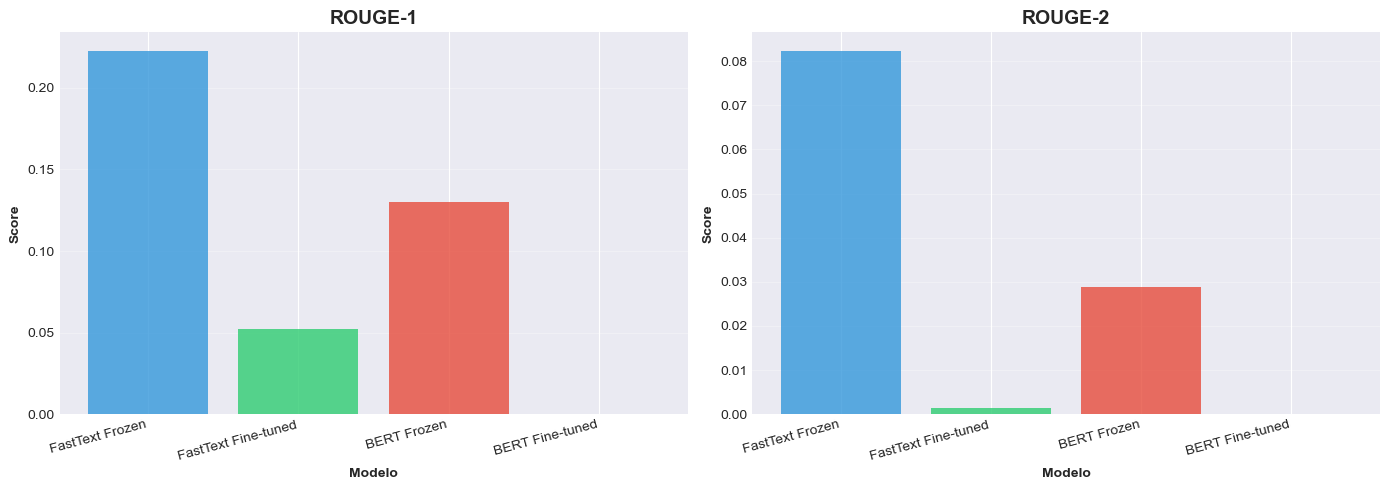


Mejor ROUGE-1: FastText Frozen (0.2229)
Mejor ROUGE-2: FastText Frozen (0.0824)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROUGE-1
x = np.arange(len(avg_results))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
axes[0].bar(x, avg_results['ROUGE-1'], color=colors, alpha=0.8)
axes[0].set_xlabel('Modelo', fontweight='bold')
axes[0].set_ylabel('Score', fontweight='bold')
axes[0].set_title('ROUGE-1', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(avg_results['Modelo'], rotation=15, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# ROUGE-2
axes[1].bar(x, avg_results['ROUGE-2'], color=colors, alpha=0.8)
axes[1].set_xlabel('Modelo', fontweight='bold')
axes[1].set_ylabel('Score', fontweight='bold')
axes[1].set_title('ROUGE-2', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(avg_results['Modelo'], rotation=15, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Mejor modelo
best_r1 = avg_results.loc[avg_results['ROUGE-1'].idxmax()]
best_r2 = avg_results.loc[avg_results['ROUGE-2'].idxmax()]
print(f"\nMejor ROUGE-1: {best_r1['Modelo']} ({best_r1['ROUGE-1']:.4f})")
print(f"Mejor ROUGE-2: {best_r2['Modelo']} ({best_r2['ROUGE-2']:.4f})")

## 9. Comparación Frozen vs Fine-tuned

In [17]:
# Mejora de fine-tuning
improvement_ft = {
    'ROUGE-1': ((avg_results.loc[1, 'ROUGE-1'] - avg_results.loc[0, 'ROUGE-1']) / avg_results.loc[0, 'ROUGE-1']) * 100,
    'ROUGE-2': ((avg_results.loc[1, 'ROUGE-2'] - avg_results.loc[0, 'ROUGE-2']) / avg_results.loc[0, 'ROUGE-2']) * 100
}

improvement_bert = {
    'ROUGE-1': ((avg_results.loc[3, 'ROUGE-1'] - avg_results.loc[2, 'ROUGE-1']) / avg_results.loc[2, 'ROUGE-1']) * 100,
    'ROUGE-2': ((avg_results.loc[3, 'ROUGE-2'] - avg_results.loc[2, 'ROUGE-2']) / avg_results.loc[2, 'ROUGE-2']) * 100
}

print("\nMejora de Fine-tuning vs Frozen:")
print("\nFastText:")
for metric, value in improvement_ft.items():
    symbol = 'mejor' if value > 0 else 'peor'
    print(f"  {symbol} {metric}: {value:+.2f}%")

print("\nBERT:")
for metric, value in improvement_bert.items():
    symbol = 'mejor' if value > 0 else 'peor'
    print(f"  {symbol} {metric}: {value:+.2f}%")


Mejora de Fine-tuning vs Frozen:

FastText:
  peor ROUGE-1: -76.60%
  peor ROUGE-2: -98.27%

BERT:
  peor ROUGE-1: -100.00%
  peor ROUGE-2: -100.00%


## 10. Ejemplos Cualitativos

In [19]:
print("="*100)
print("Pruebas de generación")
print("="*100)

examples = test_df.sample(3, random_state=SEED)

for i, (idx, row) in enumerate(examples.iterrows(), 1):
    article = row['article_text']
    reference = row['headline']
    
    gen_ft_frozen = generate_fasttext(models['fasttext_frozen'], article, vocab)
    gen_ft_finetuned = generate_fasttext(models['fasttext_finetuned'], article, vocab)
    gen_bert_frozen = generate_bert(models['bert_frozen'], article, tokenizer)
    gen_bert_finetuned = generate_bert(models['bert_finetuned'], article, tokenizer)
    
    print(f"\n{'─'*100}")
    print(f"EJEMPLO {i}")
    print(f"{'─'*100}")
    print(f"\nArtículo Seleccionado:\n{article}...")
    print(f"\nReferencia:\n{reference}")
    print(f"\nFastText Frozen (R1: {calculate_rouge_n(reference, gen_ft_frozen, 1):.3f}):\n{gen_ft_frozen}")
    print(f"\nFastText Fine-tuned (R1: {calculate_rouge_n(reference, gen_ft_finetuned, 1):.3f}):\n{gen_ft_finetuned}")
    print(f"\nBERT Frozen (R1: {calculate_rouge_n(reference, gen_bert_frozen, 1):.3f}):\n{gen_bert_frozen}")
    print(f"\nBERT Fine-tuned (R1: {calculate_rouge_n(reference, gen_bert_finetuned, 1):.3f}):\n{gen_bert_finetuned}")

print(f"\n{'='*100}")

Pruebas de generación

────────────────────────────────────────────────────────────────────────────────────────────────────
EJEMPLO 1
────────────────────────────────────────────────────────────────────────────────────────────────────

Artículo Seleccionado:
skip to navigation skip to main content skip to right column in this video: story: tesla's sales rose in several european markets in september.it comes as analysts say the ev maker risks losing ground as competition intensifies and its aging lineup remains unchanged.while sales grew in france and denmark in september for the first month this year, and continued their growth in norway and spain...tesla's new car registrations fell in sweden and the netherlands for the ninth straight month.the company has not released a new mass-market model since the model y in 2020.but it's argued that its revamped model y, released in june, would lead a recovery in european sales for 2026.tesla's competitive problems have been compounded by a back